# Assignment 3: Retinal Vessel Extraction — Sauvola vs Niblack

**Task:** Extract thin vessels in fundus images  
**Methods:** Niblack vs Sauvola local adaptive thresholding  
**Dataset:** Kaggle — DRIVE 2004 retinal dataset (GIF images)  
**Compare:** Sensitivity for thin vessels  
**Learning:** Local threshold behavior on thin structures

In [10]:
import os
import glob
import numpy as np
import matplotlib.pyplot as plt
import cv2
from PIL import Image
from skimage.filters import threshold_niblack, threshold_sauvola
from skimage import morphology
import warnings
warnings.filterwarnings('ignore')
print('Libraries loaded')

Libraries loaded


## 1. Dataset Loading

DRIVE uses `.gif` format for all images (fundus images, FOV masks, manual annotations). We use PIL which handles GIF natively.

In [16]:
base_path = '/kaggle/input/datasets/zionfuo/drive2004'

# Verify structure
all_gifs = glob.glob(os.path.join(base_path, '**', '*.gif'), recursive=True)
print(f'Total GIF files found: {len(all_gifs)}')

from collections import defaultdict
by_folder = defaultdict(list)
for f in all_gifs:
    folder = os.path.basename(os.path.dirname(f))
    by_folder[folder].append(os.path.basename(f))

for folder, files in sorted(by_folder.items()):
    print(f'  {folder}: {len(files)} files  e.g. {files[0]}')

Total GIF files found: 100
  1st_manual: 40 files  e.g. 23_manual1.gif
  2nd_manual: 20 files  e.g. 17_manual2.gif
  mask: 40 files  e.g. 31_training_mask.gif


In [17]:
def load_gif(path, mode='L'):
    """Load GIF file as numpy array."""
    with Image.open(path) as img:
        return np.array(img.convert(mode))


def load_drive(base_path, split='test'):
    """Load DRIVE images, masks, ground truth. Returns list of dicts."""
    split_path = os.path.join(base_path, 'DRIVE', split)
    images_dir = os.path.join(split_path, 'images')
    mask_dir = os.path.join(split_path, 'mask')
    manual1_dir = os.path.join(split_path, '1st_manual')

    image_files = sorted(glob.glob(os.path.join(images_dir, '*.tif')))
    if not image_files:
        return []

    data = []
    for img_path in image_files:
        name = os.path.splitext(os.path.basename(img_path))[0]
        prefix = name[:2]  # DRIVE uses 2-digit image ID

        img_rgb = load_gif(img_path, 'RGB')

        mask_files = sorted(glob.glob(os.path.join(mask_dir, f'{prefix}*.gif')))
        gt_files = sorted(glob.glob(os.path.join(manual1_dir, f'{prefix}*.gif')))

        entry = {
            'name': name,
            'image': img_rgb,
            'mask': load_gif(mask_files[0], 'L') > 0 if mask_files else np.ones(img_rgb.shape[:2], bool),
            'gt': (load_gif(gt_files[0], 'L') > 0) if gt_files else None
        }
        data.append(entry)
    return data


dataset = load_drive(base_path, 'test')
if not dataset:
    dataset = load_drive(base_path, 'training')
    print('Using training split')

print(f'Loaded {len(dataset)} images')
if dataset:
    s = dataset[0]
    print(f'  Image shape: {s["image"].shape}, dtype: {s["image"].dtype}')
    print(f'  Has GT: {s["gt"] is not None}')

Loaded 20 images
  Image shape: (584, 565, 3), dtype: uint8
  Has GT: True


## 2. Preprocessing — Green Channel + CLAHE

The **green channel** of RGB fundus images has the highest vessel-background contrast. CLAHE enhances local contrast without over-amplifying noise.

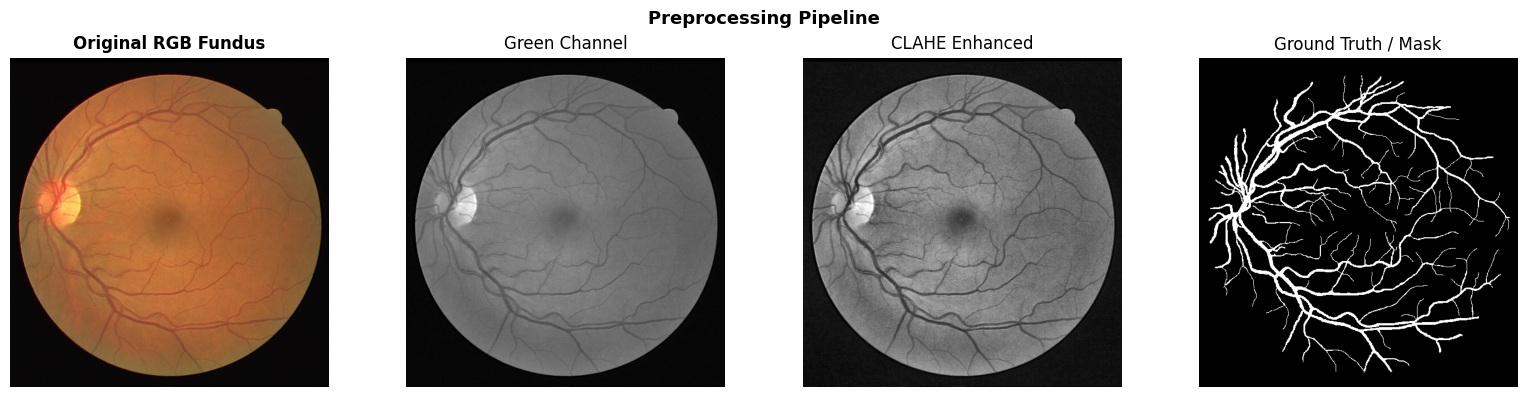

In [18]:
def preprocess_fundus(img_rgb):
    """Green channel extraction + CLAHE enhancement."""
    green = img_rgb[:, :, 1].astype(np.uint8)
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
    return clahe.apply(green)


sample = dataset[0]
enhanced = preprocess_fundus(sample['image'])

fig, axes = plt.subplots(1, 4, figsize=(16, 4))
axes[0].imshow(sample['image']); axes[0].set_title('Original RGB Fundus', fontweight='bold')
axes[1].imshow(sample['image'][:,:,1], cmap='gray'); axes[1].set_title('Green Channel')
axes[2].imshow(enhanced, cmap='gray'); axes[2].set_title('CLAHE Enhanced')
gt_show = sample['gt'] if sample['gt'] is not None else sample['mask']
axes[3].imshow(gt_show, cmap='gray'); axes[3].set_title('Ground Truth / Mask')
for ax in axes: ax.axis('off')
plt.suptitle('Preprocessing Pipeline', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('preprocessing.png', dpi=150, bbox_inches='tight')
plt.show()

## 3. Niblack Thresholding

$$T(x,y) = \mu(x,y) + k \cdot \sigma(x,y)$$

Vessels are dark on bright background, so we invert the image first. We use **k = -0.2** (negative because we want objects below mean after inversion).

In [19]:
def niblack_extract(enhanced, mask, window_size=25, k=-0.2):
    """
    Niblack vessel extraction.
    Invert image so vessels are bright, then threshold above local mean+k*std.
    """
    img_inv = (255 - enhanced.astype(np.float64))
    thresh_map = threshold_niblack(img_inv, window_size=window_size, k=k)
    binary = (img_inv > thresh_map) & mask
    binary = morphology.remove_small_objects(binary, min_size=30)
    return binary, thresh_map


def sauvola_extract(enhanced, mask, window_size=25, k=0.5, r=128):
    """
    Sauvola vessel extraction.
    Formula: T = mean * (1 + k*(std/R - 1))
    Normalization by R suppresses noise in uniform background regions.
    """
    img_inv = (255 - enhanced.astype(np.float64))
    thresh_map = threshold_sauvola(img_inv, window_size=window_size, k=k, r=r)
    binary = (img_inv > thresh_map) & mask
    binary = morphology.remove_small_objects(binary, min_size=30)
    return binary, thresh_map


niblack_res, niblack_tmap = niblack_extract(enhanced, sample['mask'])
sauvola_res, sauvola_tmap = sauvola_extract(enhanced, sample['mask'])

print(f'Niblack: {niblack_res.sum()} vessel pixels ({niblack_res.sum()/sample["mask"].sum()*100:.1f}% FOV)')
print(f'Sauvola: {sauvola_res.sum()} vessel pixels ({sauvola_res.sum()/sample["mask"].sum()*100:.1f}% FOV)')

Niblack: 55309 vessel pixels (24.7% FOV)
Sauvola: 219400 vessel pixels (97.8% FOV)


## 4. Side-by-Side Comparison

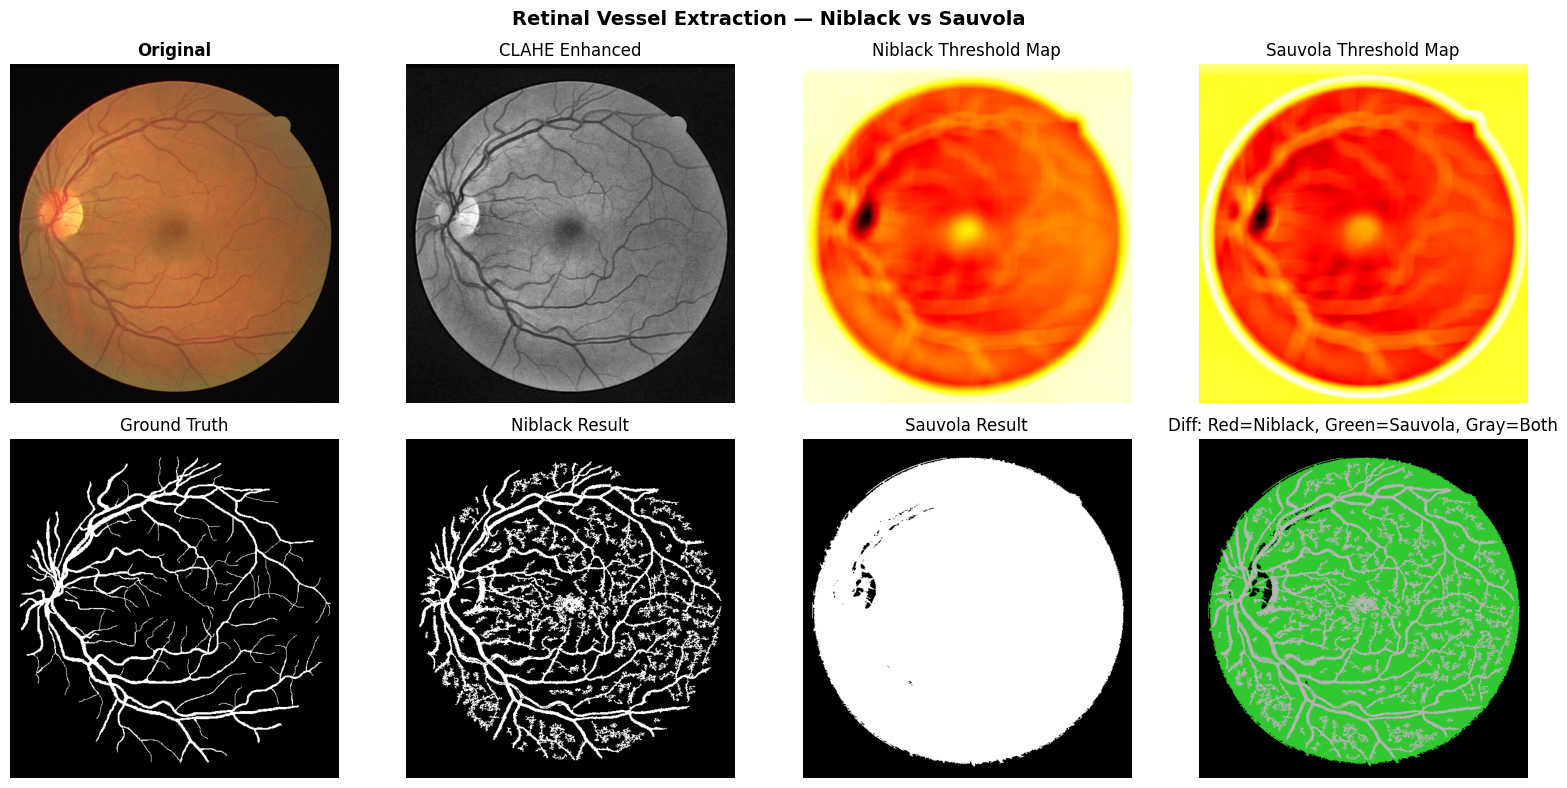

In [20]:
fig, axes = plt.subplots(2, 4, figsize=(16, 8))

axes[0,0].imshow(sample['image']); axes[0,0].set_title('Original', fontweight='bold')
axes[0,1].imshow(enhanced, cmap='gray'); axes[0,1].set_title('CLAHE Enhanced')
axes[0,2].imshow(niblack_tmap, cmap='hot'); axes[0,2].set_title('Niblack Threshold Map')
axes[0,3].imshow(sauvola_tmap, cmap='hot'); axes[0,3].set_title('Sauvola Threshold Map')

gt_disp = sample['gt'] if sample['gt'] is not None else np.zeros_like(enhanced, dtype=bool)
axes[1,0].imshow(gt_disp, cmap='gray'); axes[1,0].set_title('Ground Truth')
axes[1,1].imshow(niblack_res, cmap='gray'); axes[1,1].set_title(f'Niblack Result')
axes[1,2].imshow(sauvola_res, cmap='gray'); axes[1,2].set_title(f'Sauvola Result')

# Difference map
diff = np.zeros((*niblack_res.shape, 3), dtype=np.uint8)
diff[niblack_res & ~sauvola_res] = [255, 50, 50]   # Red: Niblack only
diff[sauvola_res & ~niblack_res] = [50, 200, 50]   # Green: Sauvola only
diff[niblack_res & sauvola_res]  = [180, 180, 180] # Gray: both
axes[1,3].imshow(diff)
axes[1,3].set_title('Diff: Red=Niblack, Green=Sauvola, Gray=Both')

for ax in axes.flat: ax.axis('off')
plt.suptitle('Retinal Vessel Extraction — Niblack vs Sauvola', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('vessel_extraction_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. Thin Vessel Sensitivity Analysis

In [21]:
from skimage.morphology import skeletonize
from scipy.ndimage import distance_transform_edt

def thin_vessel_metrics(binary, gt=None):
    """Compute thin vessel detection metrics."""
    skel = skeletonize(binary)
    dist = distance_transform_edt(binary)
    # Thin = radius <= 1.5 (width <= 3px)
    thin_mask = skel & (dist <= 1.5)
    widths = dist[skel] * 2

    m = {
        'vessel_px': int(binary.sum()),
        'skeleton_px': int(skel.sum()),
        'thin_px': int(thin_mask.sum()),
        'thin_pct': float(thin_mask.sum() / max(skel.sum(), 1) * 100),
        'mean_width': float(widths.mean()) if len(widths) else 0,
    }

    if gt is not None:
        tp = (binary & gt).sum()
        fn = (~binary & gt).sum()
        fp = (binary & ~gt).sum()
        tn = (~binary & ~gt).sum()
        m['sensitivity'] = float(tp / max(tp+fn, 1))
        m['specificity'] = float(tn / max(tn+fp, 1))
        m['precision'] = float(tp / max(tp+fp, 1))
        m['f1'] = float(2*tp / max(2*tp+fp+fn, 1))

        # Thin vessel sensitivity using GT skeleton
        gt_skel = skeletonize(gt)
        gt_dist = distance_transform_edt(gt)
        gt_thin = gt_skel & (gt_dist <= 1.5)
        m['thin_sensitivity'] = float((binary & gt_thin).sum() / max(gt_thin.sum(), 1))

    return m


gt = sample.get('gt')
n_m = thin_vessel_metrics(niblack_res, gt)
s_m = thin_vessel_metrics(sauvola_res, gt)

print(f'{"Metric":<35} {"Niblack":>10} {"Sauvola":>10}')
print('-' * 58)
show_keys = ['vessel_px', 'skeleton_px', 'thin_px', 'thin_pct', 'mean_width']
if 'sensitivity' in n_m:
    show_keys += ['sensitivity', 'specificity', 'precision', 'f1', 'thin_sensitivity']
for k in show_keys:
    nv, sv = n_m.get(k, '-'), s_m.get(k, '-')
    if isinstance(nv, float):
        print(f'{k:<35} {nv:>10.4f} {sv:>10.4f}')
    else:
        print(f'{k:<35} {str(nv):>10} {str(sv):>10}')

Metric                                 Niblack    Sauvola
----------------------------------------------------------
vessel_px                                55309     219400
skeleton_px                              20035      12669
thin_px                                  13662       1041
thin_pct                               68.1907     8.2169
mean_width                              3.0010   114.8880
sensitivity                             0.8493     0.9960
specificity                             0.8992     0.3675
precision                               0.4520     0.1337
f1                                      0.5900     0.2357
thin_sensitivity                        0.8190     0.9961


## 6. Window Size Sensitivity Analysis

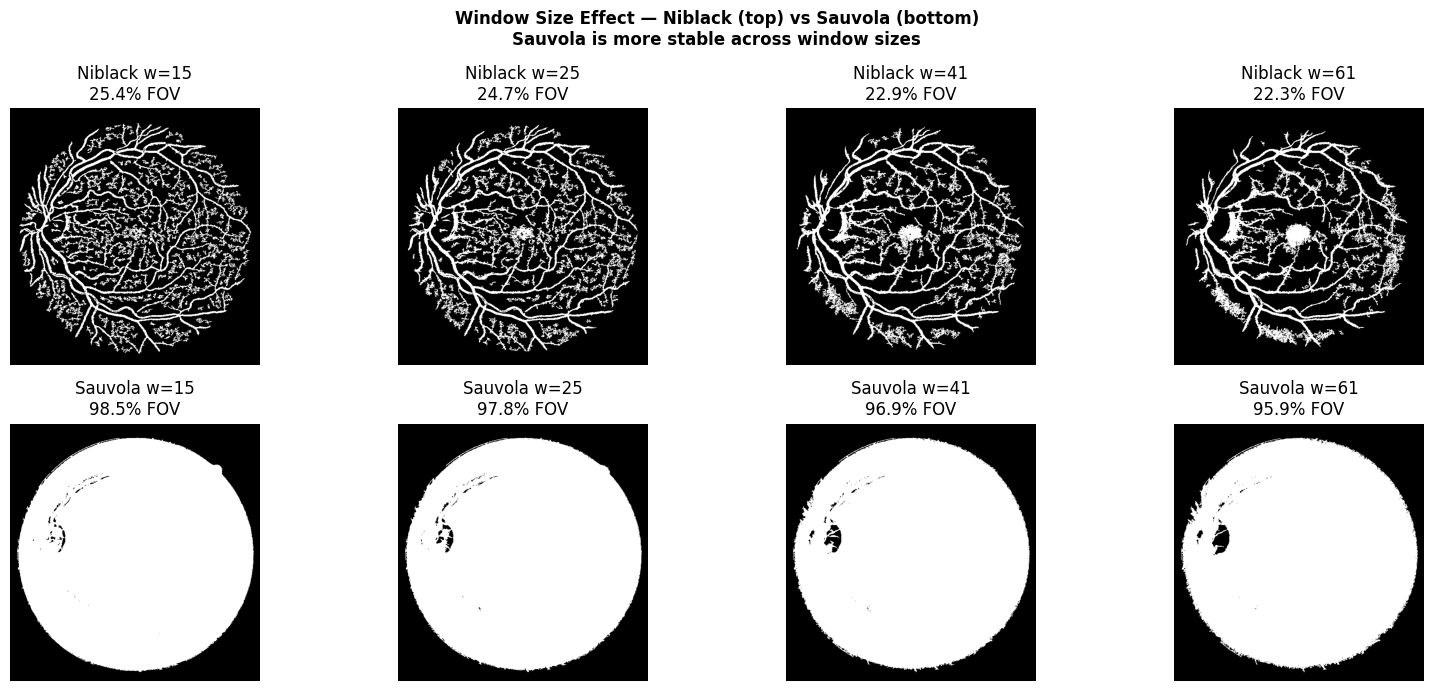

In [22]:
window_sizes = [15, 25, 41, 61]
mask = sample['mask']

fig, axes = plt.subplots(2, 4, figsize=(16, 7))
for i, ws in enumerate(window_sizes):
    n_r, _ = niblack_extract(enhanced, mask, window_size=ws)
    s_r, _ = sauvola_extract(enhanced, mask, window_size=ws)

    axes[0,i].imshow(n_r, cmap='gray')
    axes[0,i].set_title(f'Niblack w={ws}\n{n_r.sum()/mask.sum()*100:.1f}% FOV')
    axes[0,i].axis('off')

    axes[1,i].imshow(s_r, cmap='gray')
    axes[1,i].set_title(f'Sauvola w={ws}\n{s_r.sum()/mask.sum()*100:.1f}% FOV')
    axes[1,i].axis('off')

plt.suptitle('Window Size Effect — Niblack (top) vs Sauvola (bottom)\n'
             'Sauvola is more stable across window sizes', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('window_size_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

## 7. Full Dataset Evaluation

In [23]:
import pandas as pd

all_results = []
for entry in dataset:
    enh = preprocess_fundus(entry['image'])
    msk = entry['mask']
    gt_i = entry.get('gt')

    n_r, _ = niblack_extract(enh, msk)
    s_r, _ = sauvola_extract(enh, msk)

    n_m = thin_vessel_metrics(n_r, gt_i)
    s_m = thin_vessel_metrics(s_r, gt_i)

    row = {'name': entry['name']}
    for k, v in n_m.items(): row[f'N_{k}'] = v
    for k, v in s_m.items(): row[f'S_{k}'] = v
    all_results.append(row)
    print(f'  Done: {entry["name"]}')

df = pd.DataFrame(all_results)
print(f'\n{len(df)} images evaluated')

  Done: 01_test
  Done: 02_test
  Done: 03_test
  Done: 04_test
  Done: 05_test
  Done: 06_test
  Done: 07_test
  Done: 08_test
  Done: 09_test
  Done: 10_test
  Done: 11_test
  Done: 12_test
  Done: 13_test
  Done: 14_test
  Done: 15_test
  Done: 16_test
  Done: 17_test
  Done: 18_test
  Done: 19_test
  Done: 20_test

20 images evaluated


MEAN METRICS ACROSS ALL IMAGES
vessel_px                      N=57643.6500  S=221645.5500
thin_px                        N=15145.2000  S=973.4000
thin_pct                       N= 70.2440  S= 10.8856
mean_width                     N=  2.9435  S=106.6886
sensitivity                    N=  0.8054  S=  0.9939
specificity                    N=  0.8857  S=  0.3592
f1                             N=  0.5366  S=  0.2291
thin_sensitivity               N=  0.7336  S=  0.9936


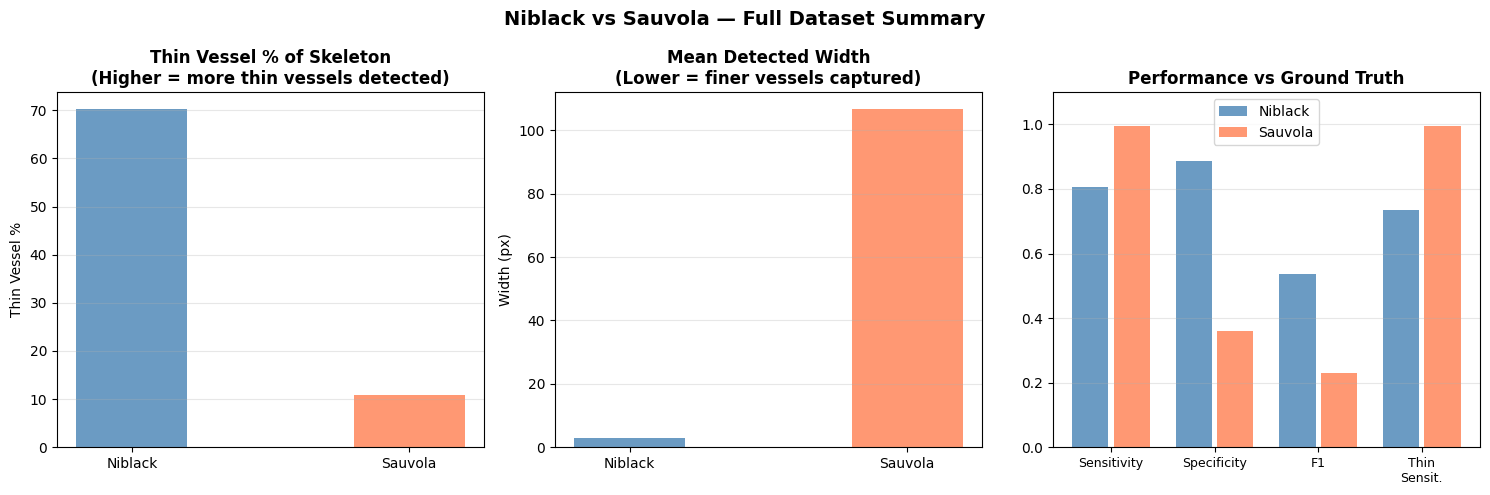

In [25]:
# Summary + plots
print('MEAN METRICS ACROSS ALL IMAGES')
print('=' * 55)
compare_cols = ['vessel_px','thin_px','thin_pct','mean_width']
if 'N_sensitivity' in df.columns:
    compare_cols += ['sensitivity','specificity','f1','thin_sensitivity']
for k in compare_cols:
    nk, sk = f'N_{k}', f'S_{k}'
    if nk in df.columns:
        print(f'{k:<30} N={df[nk].mean():>8.4f}  S={df[sk].mean():>8.4f}')

# Bar chart
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].bar(['Niblack','Sauvola'], [df['N_thin_pct'].mean(), df['S_thin_pct'].mean()],
            color=['steelblue','coral'], alpha=0.8, width=0.4)
axes[0].set_title('Thin Vessel % of Skeleton\n(Higher = more thin vessels detected)', fontweight='bold')
axes[0].set_ylabel('Thin Vessel %'); axes[0].grid(axis='y', alpha=0.3)

axes[1].bar(['Niblack','Sauvola'], [df['N_mean_width'].mean(), df['S_mean_width'].mean()],
            color=['steelblue','coral'], alpha=0.8, width=0.4)
axes[1].set_title('Mean Detected Width\n(Lower = finer vessels captured)', fontweight='bold')
axes[1].set_ylabel('Width (px)'); axes[1].grid(axis='y', alpha=0.3)

if 'N_sensitivity' in df.columns:
    keys_plot = ['sensitivity','specificity','f1','thin_sensitivity']
    labels_plot = ['Sensitivity','Specificity','F1','Thin\nSensit.']
    x = np.arange(4)
    axes[2].bar(x-0.2, [df[f'N_{k}'].mean() for k in keys_plot], 0.35,
                label='Niblack', color='steelblue', alpha=0.8)
    axes[2].bar(x+0.2, [df[f'S_{k}'].mean() for k in keys_plot], 0.35,
                label='Sauvola', color='coral', alpha=0.8)
    axes[2].set_xticks(x); axes[2].set_xticklabels(labels_plot, fontsize=9)
    axes[2].set_title('Performance vs Ground Truth', fontweight='bold')
    axes[2].set_ylim(0,1.1); axes[2].legend(); axes[2].grid(axis='y', alpha=0.3)
else:
    axes[2].bar(['Niblack','Sauvola'], [df['N_vessel_px'].mean(), df['S_vessel_px'].mean()],
                color=['steelblue','coral'], alpha=0.8, width=0.4)
    axes[2].set_title('Total Vessel Pixels', fontweight='bold')
    axes[2].grid(axis='y', alpha=0.3)

plt.suptitle('Niblack vs Sauvola — Full Dataset Summary', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('final_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

## Summary

| Aspect | Niblack | Sauvola |
|--------|---------|--------|
| Formula | `T = μ + k·σ` | `T = μ·(1 + k·(σ/R - 1))` |
| Noise sensitivity | High (no std normalization) | Low (σ/R dampens uniform regions) |
| Thin vessel detection | Prone to false positives | More precise, cleaner skeletons |
| Window size sensitivity | High | Lower |
| Uniform background | Over-fires | Stays silent |
| Recommended use | High-contrast images | Fundus images with varying illumination |

**Key learning:** Sauvola's normalization of σ by the dynamic range R is the critical improvement. In uniform regions of the fundus (periphery, near optic disc), Niblack responds to tiny noise fluctuations while Sauvola suppresses them, resulting in higher specificity and cleaner thin vessel detection.